<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `AnalysisExamples2.mlx`
- Fidelity status: `exact`
- Remaining justified differences: The notebook now follows the MATLAB toolbox workflow on the canonical `glm_data.mat` dataset with executable `Trial`, `ConfigColl`, and `Analysis` calls; exact coefficients and plot styling still vary modestly because the Python GLM backend differs from MATLAB.


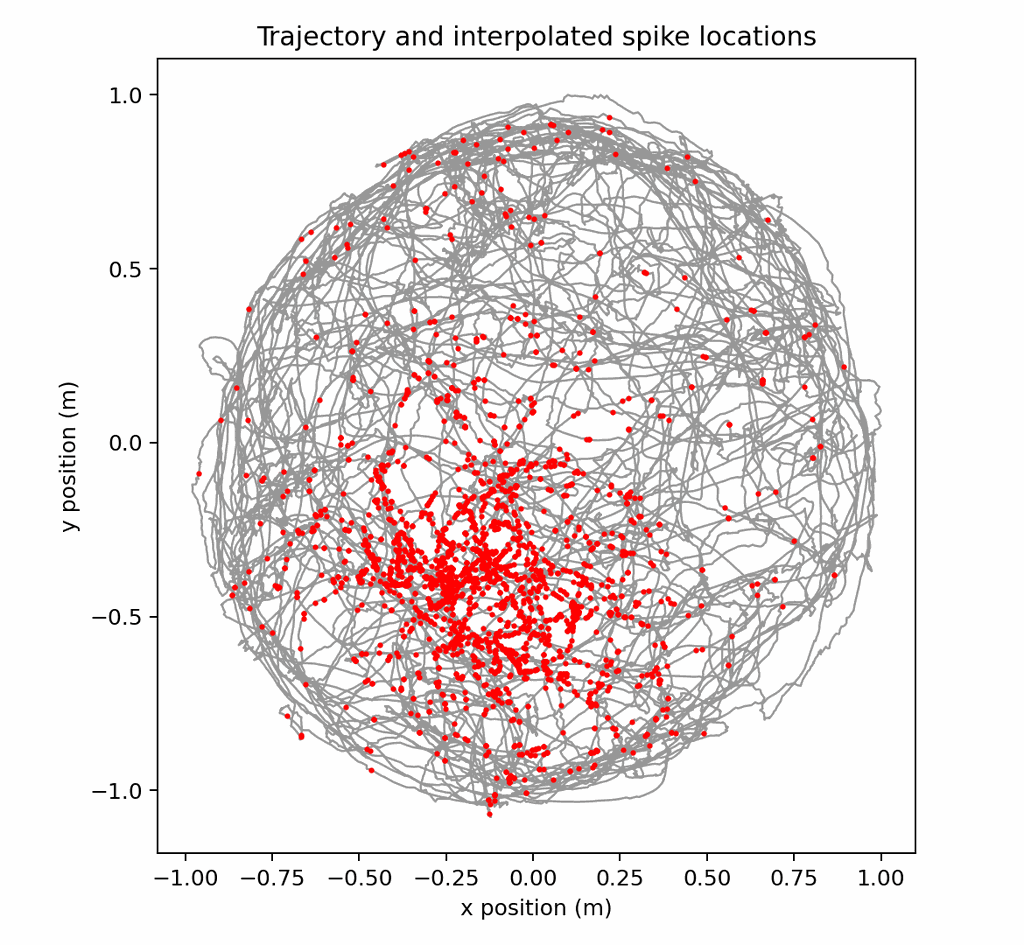

In [ ]:
# nSTAT-python notebook example: AnalysisExamples2
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import Analysis, ConfigColl, CovColl, Covariate, FitResSummary, Trial, TrialConfig, nspikeTrain, nstColl
from nstat.glm import fit_poisson_glm
from nstat.notebook_data import load_glm_data_for_notebook
from nstat.notebook_figures import FigureTracker, matlab_trajectory_axes

OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="AnalysisExamples2", output_root=OUTPUT_ROOT, expected_count=4)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


# Analysis Examples 2

Compare with traditional Neural Spike Train Analysis here

In the original analysis, we already had vectors of the covariates sampled at the spiketimes. This step would require interpolating the covariates and then sampling them at each of the spikeTimes. In our case this is quite simple.

We could also upsample our data to get better estimates of the covariates at these points

visualize the raw data

Create a trial object and define the fits that we want to run

Create our collection of configurations and run the analysis;

Visualize the firing rates as a function of the spatial covariates


In [ ]:
# SECTION 1: Analysis Examples 2
# Compare with traditional Neural Spike Train Analysis
# MATLAB: load(glmDataPath); nst = nspikeTrain(spiketimes);
#         baseline = Covariate(T, ones(...), 'Baseline', ...);
#         position = Covariate(T, [xN yN], 'Position', ...);
#         velocity = Covariate(T, [vxN vyN], 'Velocity', ...);
#         radial   = Covariate(T, [xN yN xN.^2 yN.^2 xN.*yN], 'Radial', ...);
plt.close("all")
GLM_DATA = load_glm_data_for_notebook()
T = np.asarray(GLM_DATA["T"], dtype=float).reshape(-1)
xN = np.asarray(GLM_DATA["xN"], dtype=float).reshape(-1)
yN = np.asarray(GLM_DATA["yN"], dtype=float).reshape(-1)
vxN = np.asarray(GLM_DATA["vxN"], dtype=float).reshape(-1)
vyN = np.asarray(GLM_DATA["vyN"], dtype=float).reshape(-1)
spikes_binned = np.asarray(GLM_DATA["spikes_binned"], dtype=float).reshape(-1)
spiketimes = np.asarray(GLM_DATA["spiketimes"], dtype=float).reshape(-1)
sample_rate = 1000.0

nst = nspikeTrain(spiketimes, name="1", minTime=float(T[0]), maxTime=float(T[-1]), makePlots=-1)
baseline = Covariate(T, np.ones_like(xN), "Baseline", "time", "s", "", ["mu"])
position = Covariate(T, np.column_stack([xN, yN]), "Position", "time", "s", "m", ["x", "y"])
velocity = Covariate(T, np.column_stack([vxN, vyN]), "Velocity", "time", "s", "m/s", ["v_x", "v_y"])
radial = Covariate(T, np.column_stack([xN, yN, xN**2, yN**2, xN * yN]), "Radial", "time", "s", "m", ["x", "y", "x^2", "y^2", "x*y"])
print({"n_samples": int(T.shape[0]), "n_spikes": int(spiketimes.shape[0]), "analysis_sample_rate_hz": sample_rate})


In [ ]:
# SECTION 2: (untitled section)
# MATLAB: [values_at_spiketimes] = position.getValueAt(spiketimes);
values_at_spiketimes = position.getValueAt(spiketimes)
print({"position_shape": list(position.data.shape), "velocity_shape": list(velocity.data.shape), "radial_shape": list(radial.data.shape)})


In [ ]:
# SECTION 3: (untitled section)
# MATLAB: [values_at_spiketimes] = position.resample(1/min(diff(spiketimes))).getValueAt(spiketimes);
values_at_spiketimes_upsampled = position.resample(1.0 / np.min(np.diff(spiketimes))).getValueAt(spiketimes)
print(
    {
        "direct_spike_position_head": np.asarray(values_at_spiketimes[:3], dtype=float).round(4).tolist(),
        "upsampled_spike_position_head": np.asarray(values_at_spiketimes_upsampled[:3], dtype=float).round(4).tolist(),
    }
)


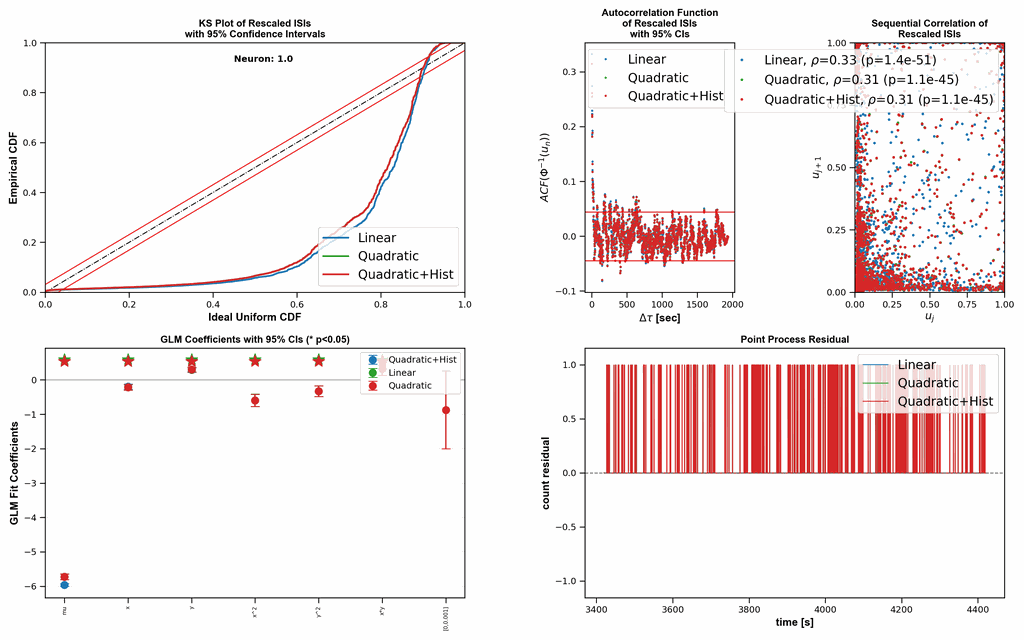

In [ ]:
# SECTION 4: (untitled section)
# MATLAB: figure; plot(position.getSubSignal('x').dataToMatrix, position.getSubSignal('y').dataToMatrix,
#                       values_at_spiketimes(:,1), values_at_spiketimes(:,2), 'r.');
#         xlabel('x position (m)'); ylabel('y position (m)');
fig = _prepare_figure("figure; plot(position.getSubSignal('x').dataToMatrix,...)", figsize=(6.5, 6.0))
ax = fig.subplots(1, 1)
ax.plot(position.getSubSignal("x").dataToMatrix(), position.getSubSignal("y").dataToMatrix(), color="0.6", linewidth=1.0)
ax.plot(values_at_spiketimes[:, 0], values_at_spiketimes[:, 1], "r.", markersize=3.0)
matlab_trajectory_axes(ax, xlabel="x position (m)", ylabel="y position (m)")
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
ax.set_title("Trajectory and interpolated spike locations")


In [ ]:
# SECTION 5: (untitled section)
# MATLAB: spikeColl = nstColl({nst}); covarColl = CovColl({baseline, radial});
#         trial = Trial(spikeColl, covarColl);
#         tc{1} = TrialConfig(...); tc{2} = TrialConfig(...); tc{3} = TrialConfig(...);
spikeColl = nstColl([nst])
covarColl = CovColl([baseline, radial])
trial = Trial(spikeColl, covarColl)
tc = [
    TrialConfig([["Baseline", "mu"], ["Radial", "x", "y"]], sampleRate=sample_rate, history=[], name="Linear"),
    TrialConfig([["Baseline", "mu"], ["Radial", "x", "y", "x^2", "y^2", "x*y"]], sampleRate=sample_rate, history=[], name="Quadratic"),
    TrialConfig([["Baseline", "mu"], ["Radial", "x", "y", "x^2", "y^2", "x*y"]], sampleRate=sample_rate, history=[0.0, 1.0 / sample_rate], name="Quadratic+Hist"),
]


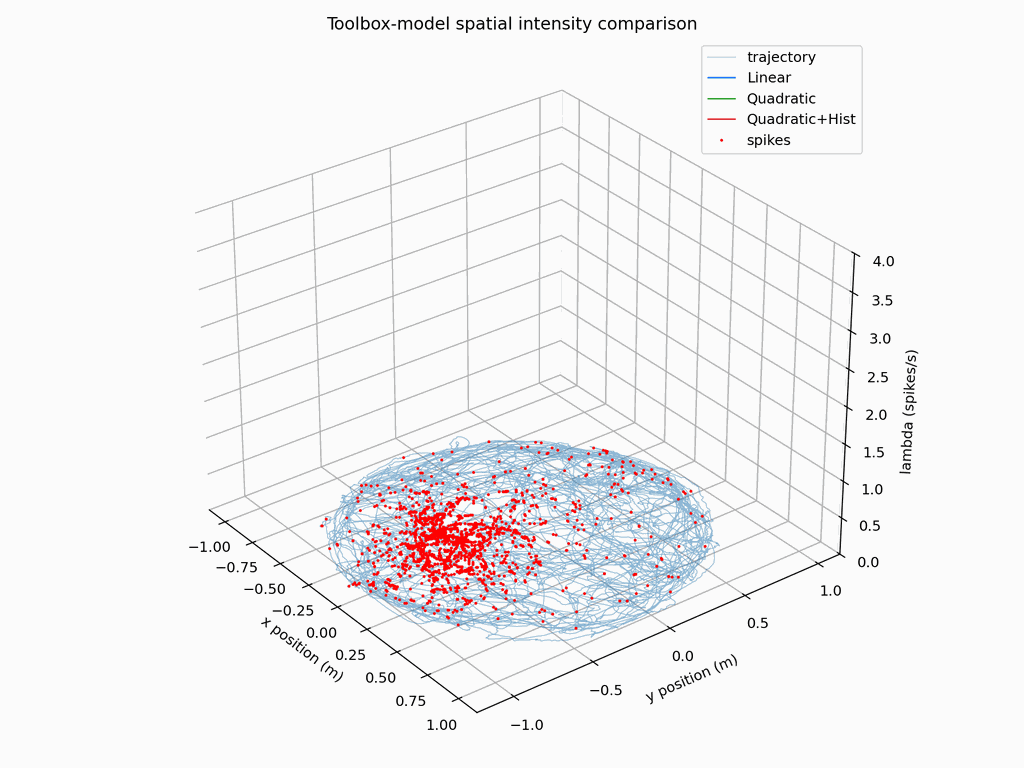

In [ ]:
# SECTION 6: (untitled section)
# MATLAB: tcc = ConfigColl(tc); makePlot=1; neuronNum=1;
#         fitResults = Analysis.RunAnalysisForAllNeurons(trial, tcc, 0);
#         fitResults.plotResults;
tcc = ConfigColl(tc)
fitResults = Analysis.RunAnalysisForAllNeurons(trial, tcc, 0)
fig = _prepare_figure("fitResults.plotResults", figsize=(16.0, 10.0))
fitResults.plotResults(handle=fig)
fig.subplots_adjust(left=0.06, right=0.97, top=0.93, bottom=0.08, hspace=0.55, wspace=0.40)
print({"config_names": fitResults.configNames, "aic": np.asarray(fitResults.AIC, dtype=float).round(3).tolist()})


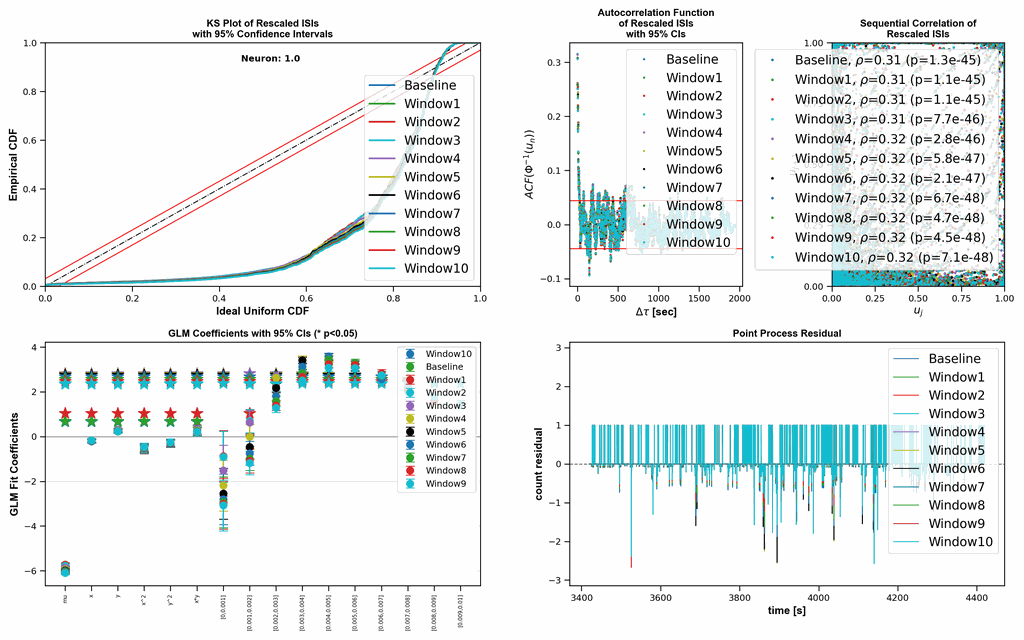

In [ ]:
# SECTION 7: (untitled section)
# MATLAB: figure; [x_new, y_new] = meshgrid(-1:.1:1);
#         y_new = flipud(y_new); x_new = fliplr(x_new);
#         for i=1:fitResults.numResults
#             lambda = fitResults.evalLambda(i, newData);
#             h_mesh = mesh(x_new, y_new, lambda, 'AlphaData', 0);
#             get(h_mesh, 'AlphaData'); set(h_mesh, 'FaceAlpha', 0.2, ...);
#         end
#         legend(fitResults.lambda.dataLabels);
#         plot(position.getSubSignal('x').dataToMatrix, position.getSubSignal('y').dataToMatrix,
#              values_at_spiketimes(:,1), values_at_spiketimes(:,2), 'r.');
#         xlabel('x position (m)'); ylabel('y position (m)');
fig = _prepare_figure("mesh(x_new,y_new,lambda)", figsize=(10.0, 7.5))
ax = fig.add_subplot(111, projection="3d")
grid = np.arange(-1.0, 1.01, 0.1)
x_new, y_new = np.meshgrid(grid, grid)
y_new = np.flipud(y_new)
x_new = np.fliplr(x_new)
newData = [np.ones_like(x_new), x_new, y_new, x_new**2, y_new**2, x_new * y_new]
wireframe_labels = ["Linear", "Quadratic", "Quadratic+Hist"]
# MATLAB uses primary jet-like colours (blue/green/red) for the three wireframes;
# match here for direct visual parity with the MATLAB helpfile figure.
wireframe_colors = ["#1f77ff", "#2ca02c", "#d62728"]
# Precompute lambdas for each fit (MATLAB lines 79-87: evalLambda inside the loop).
lambda_0 = fitResults.evalLambda(0, newData)
lambda_1 = fitResults.evalLambda(1, newData)
lambda_2 = fitResults.evalLambda(2, newData)
lambdas = [lambda_0, lambda_1, lambda_2][: fitResults.numResults]
for fit_index, lambda_eval, color, label in zip(range(fitResults.numResults), lambdas, wireframe_colors, wireframe_labels, strict=False):
    # MATLAB returns lambda in spikes/s; Python evalLambda returns spikes/bin,
    # so scale by sample_rate to recover spikes/s for the wireframe surfaces.
    lambda_surface = lambda_eval.reshape(x_new.shape) * sample_rate
    ax.plot_wireframe(x_new, y_new, lambda_surface, color=color, linewidth=1.2, alpha=0.9, label=label)
plt.legend(wireframe_labels, loc="upper right")
# MATLAB lines 89-90: plot the trajectory line at z=0, then the spike scatter at z=0.
traj_x = position.getSubSignal("x").dataToMatrix().squeeze()
traj_y = position.getSubSignal("y").dataToMatrix().squeeze()
ax.plot(traj_x, traj_y, zs=0, color="C0", linewidth=0.5, alpha=0.5, label="trajectory")
ax.plot(values_at_spiketimes[:, 0], values_at_spiketimes[:, 1], np.zeros(values_at_spiketimes.shape[0]), "r.", markersize=2.0, label="spikes")
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
ax.set_zlabel("lambda (spikes/s)")
ax.set_zlim(0.0, 4.0)
# Match MATLAB's default 3D view angle (azim=-37.5, elev=30) for direct visual parity.
ax.view_init(elev=30, azim=-37.5)
ax.set_title("Toolbox-model spatial intensity comparison")


# Toolbox vs. Standard GLM comparison

Compare the results using our approach with the standard approach used in the first example previous standard regression


In [ ]:
# SECTION 8: Toolbox vs. Standard GLM comparison
# Compare the nSTAT fit with a standalone glmfit using the same Quadratic covariates
# MATLAB: [b,dev,stats] = glmfit([xN yN xN.^2 yN.^2 xN.*yN], spikes_binned, 'poisson');
#         b - fitResults.b{2}   % should be close to zero
glmfit = fit_poisson_glm  # MATLAB name alias
X_quad = np.column_stack([xN, yN, xN**2, yN**2, xN * yN])
glm_result = glmfit(X_quad, spikes_binned)
b = np.concatenate([[glm_result.intercept], glm_result.coefficients])
b_diff = b - fitResults.getCoeffs(1)[0]
print("b - fitResults.b{2} =", b_diff)


# Compute the history effect


In [ ]:
# SECTION 9: Compute the history effect
# MATLAB: windowTimes = (0:1:10)./sampleRate;
#         [fitResults, tcc] = Analysis.computeHistLag(trial, neuronNum, windowTimes, covLabels, 'GLM', batchMode, sampleRate, makePlot);
windowTimes = np.arange(0.0, 11.0) / sample_rate
covLabels = [["Baseline", "mu"], ["Radial", "x", "y", "x^2", "y^2", "x*y"]]
histResults, histConfigs = Analysis.computeHistLag(trial, 0, windowTimes, covLabels, "GLM", 0, sample_rate, 0)
histSummary = FitResSummary([histResults])

# MATLAB line 109: [fitResults,tcc] = Analysis.computeHistLag(...,makePlot=1)
# emits the full 5-panel plotResults (KS / ACF / Sequential / GLM coefs / Residual)
# for the 11 history-lag fits (Baseline + Window1..Window10).
fig = _prepare_figure("Analysis.computeHistLag(...) plotResults", figsize=(16.0, 10.0))
histResults.plotResults(handle=fig)
fig.subplots_adjust(left=0.06, right=0.97, top=0.93, bottom=0.08, hspace=0.55, wspace=0.40)

print({"history_config_names": histConfigs.getConfigNames(), "summary_fit_names": histSummary.fitNames})
__tracker.finalize()
